# **Reasons Behind Low Customers Ratings (LCR):**

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
data= pd.read_json("data.json")

In [4]:
data.shape

(10999, 12)

In [5]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [6]:
data.head(3)

,id,warehouse_block,mode_of_shipment,customer_care_calls,customer_rating,cost_of_product,prior_purchase,product_importance,gender,discount_offered,weight_gms,reached_on_time
0,1,D,Flight,4,2,177,3,low,F,44,1233,1
1,2,F,Flight,4,5,216,2,low,M,59,3088,1
2,3,A,Flight,2,2,183,4,low,M,48,3374,1


> In this analysis, we focus on the `Customer_ratings` and try to improve customer satisfaction.

## **11. Distribution of Customer Ratings:**

In [7]:
data["customer_rating"].head(4)

0    2
1    5
2    2
3    3
Name: customer_rating, dtype: int64

In [8]:
data["customer_rating"].unique()

array([2, 5, 3, 1, 4])

In [11]:
cus_rat= data["customer_rating"].value_counts().reset_index()
cus_rat

,customer_rating,count
0,3,2239
1,1,2235
2,4,2189
3,5,2171
4,2,2165


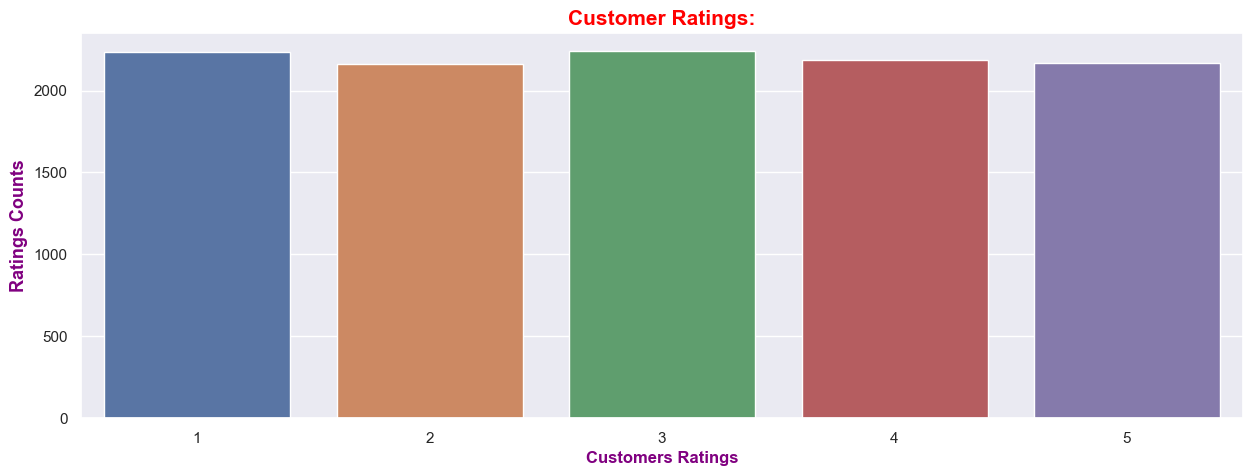

In [18]:
plt.figure(figsize= (15, 5))
sns.set_theme(context= "notebook", style= "darkgrid", palette= "deep")
sns.barplot(data= cus_rat, x= "customer_rating", y= "count", palette= "deep", hue= "customer_rating", legend=False)
plt.title("Customer Ratings:", fontsize= 15, fontweight= "bold", color= "red", loc= "center")
plt.xlabel("Customers Ratings", fontsize= 12, fontweight= "bold", color= "purple")
plt.ylabel("Ratings Counts", fontsize= 13, fontweight= "bold", color= "purple")
plt.show()

SO, there is no high-disbalance in the number of ratings for each rating class. 

---
---
---

## **12. Correlation between Late Deliveries and Ratings:**

In [21]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

To know the linear/ monotonic relation between columns "reached_on_time" and "customer_rating", we can calculate the correlation between them:

In [23]:
data[["reached_on_time", "customer_rating"]].corr(method= "pearson")

,reached_on_time,customer_rating
reached_on_time,1.000000,0.013119
customer_rating,0.013119,1.000000


This shows a very low positive correlation and so there is almost no linear relationship between `reached_on_time` and `customer_rating`.

Since the correlation is close to 0, we can conclude that being "on time" in reaching a customer does not significantly affect their ratings. 

There are various other factors affecting the ratings of products and modeling this relation linearly with `"product on-time delivery"` don't clearly explain their true dependency and influence.

**Check if Late Deliveries Affects Customers Ratings:**

In [37]:
late_del= data.groupby(by= "reached_on_time")["customer_rating"].value_counts(normalize= True).reset_index()
late_del

,reached_on_time,customer_rating,proportion
0,0,1,0.207845
1,0,2,0.201082
2,0,4,0.199729
3,0,3,0.198828
4,0,5,0.192516
5,1,3,0.206765
6,1,5,0.200670
7,1,1,0.200061
8,1,4,0.198537
9,1,2,0.193966


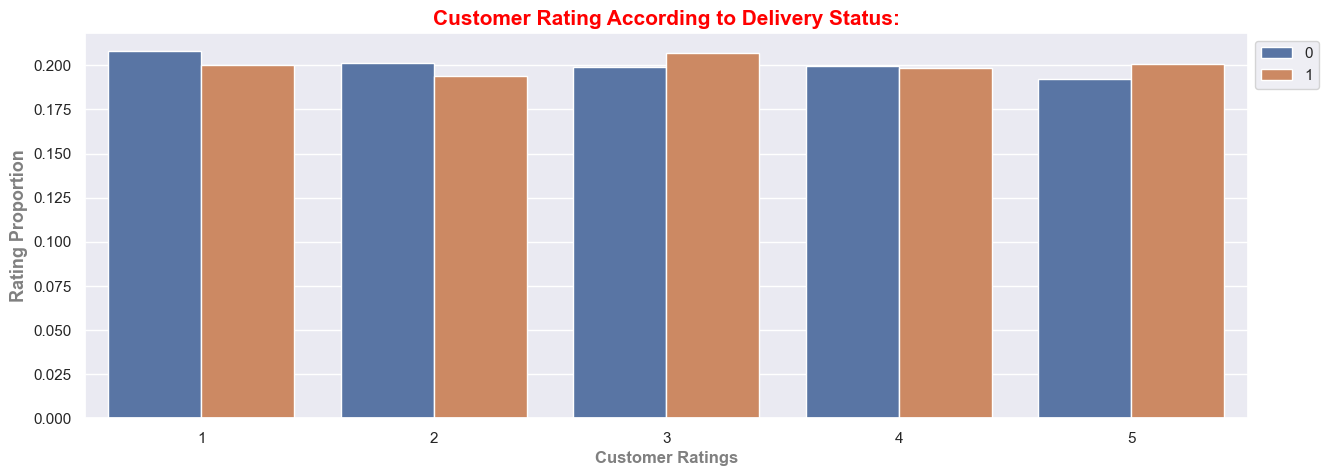

In [38]:
plt.figure(figsize= (15, 5))
sns.barplot(data= late_del, x= "customer_rating", y= "proportion", hue= "reached_on_time")
# Plot legend outside the plot to avoide overlapping: 
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.title("Customer Rating According to Delivery Status:", color= "red", fontsize= 15, fontweight= "bold")
plt.xlabel("Customer Ratings", color= "gray", fontweight= "bold", fontsize= 12)
plt.ylabel("Rating Proportion", color= "gray", fontsize= 13, fontweight= "bold")
plt.show()

In [39]:
late_dels= data.groupby(by= "reached_on_time")["customer_rating"].mean().reset_index()
late_dels

,reached_on_time,customer_rating
0,0,2.967989
1,1,3.005790


There is no bias in the ratings according to if the product is delivered on time or it is late.

----
---
----

## **13. Impact of Customer Care Calls on Ratings:** 


* **Description:** Analyze the relationship between the number of support calls and the final customer rating.
* **How to do it in Python:** Create a `boxplot` or a `violinplot` with `x='Customer_rating'` and `y='Customer_care_calls'` to see if lower ratings are associated with more calls.

In [47]:
data.columns

Index(['id', 'warehouse_block', 'mode_of_shipment', 'customer_care_calls',
       'customer_rating', 'cost_of_product', 'prior_purchase',
       'product_importance', 'gender', 'discount_offered', 'weight_gms',
       'reached_on_time'],
      dtype='object')

In [53]:
data[['customer_care_calls', 'reached_on_time', "customer_rating"]].head()

,customer_care_calls,reached_on_time,customer_rating
0,4,1,2
1,4,1,5
2,2,1,2
3,3,1,3
4,2,1,2


In [54]:
data["customer_care_calls"].unique()

array([4, 2, 3, 5, 6, 7])

In [55]:
data["customer_rating"].unique()

array([2, 5, 3, 1, 4])